#  Feature Selection : Hypertension Risk Atlas
**ADS-599 Capstone Project · Group 2 · Nancy Walker & Michelle Wang**

---

This notebook employs Least Absolute Shrinkage and Selection Operator (LASSO) L1 regularization to conduct feature selection for predicting hypertension risk. By utilizing L1 regularization, this analysis identifies and prunes non-contributory variables, effectively reducing model complexity while retaining key predictive drivers. This process serves as a foundational step in establishing robust machine learning parameters. Furthermore, the findings from this analysis will inform the construction of future modeling pipelines, ensuring that feature selection and dimensionality reduction are integrated directly into the training process to maintain strict prevention of data leakage.

# 1. Import Libraries

In [40]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Publication color registry shared with EDA and modeling.
VARIABLE_COLORS = {
    "DIABETES": "#1F77B4", "MOBILITY": "#AEC7E8",
    "FOODINSECU": "#FF7F0E", "SELFCARE": "#FFBB78",
    "HOUSINSECU": "#2CA02C", "LACKTRPT": "#98DF8A",
    "LPA": "#D62728", "GHLTH": "#FF9896",
    "COPD": "#9467BD", "SLEEP": "#C5B0D5",
    "COGNITION": "#8C564B", "FOODSTAMP": "#C49C94",
    "VISION": "#E377C2", "TEETHLOST": "#F7B6D2",
    "OBESITY": "#7F7F7F", "LONELINESS": "#C7C7C7",
    "CSMOKING": "#BCBD22", "EMOTIONSPT": "#17BECF",
    "CASTHMA": "#393B79", "ACCESS2": "#BD9E39",
    "LILATracts_1And10": "#637939", "LowIncomeTracts": "#8C6D31",
    "NUMGQTRS": "#843C39", "PCA_Component_2": "#7B4173",
    "LILATracts_halfAnd10": "#5254A3",
}
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# 2. Load the Data 

In [41]:
# Path setup
base_path = Path.cwd().parents[1]
processed_dir = base_path / "data" / "processed" 

# Ensure the folder exists (best practice)
processed_dir.mkdir(parents=True, exist_ok=True)

# Load the files
X_train = pd.read_csv(processed_dir / "X_train_block_pca.csv", index_col=0)
X_test = pd.read_csv(processed_dir / "X_test_block_pca.csv", index_col=0)
y_train = pd.read_csv(processed_dir / "y_train_block_pca.csv", index_col=0)
y_test = pd.read_csv(processed_dir / "y_test_block_pca.csv", index_col=0)

# Quick verification
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")


Train shape: (2364, 43)
Test shape: (592, 43)


LASSO requires all input features to be numerical to perform scaling and mathematical regularization, it will crash when it finds a text string.

In [42]:
# Check data types 
print(f"Train data types:\n{X_train.dtypes}")
print(f"Test data types:\n{X_test.dtypes}")

Train data types:
fipscode                  int64
locationname             object
stateabbr                object
ACCESS2                 float64
CASTHMA                 float64
COGNITION               float64
COPD                    float64
CSMOKING                float64
DIABETES                float64
EMOTIONSPT              float64
FOODINSECU              float64
FOODSTAMP               float64
GHLTH                   float64
HOUSINSECU              float64
LONELINESS              float64
LPA                     float64
MOBILITY                float64
OBESITY                 float64
SELFCARE                float64
SLEEP                   float64
TEETHLOST               float64
VISION                  float64
Pop2010                 float64
OHU2010                 float64
NUMGQTRS                float64
Urban                   float64
GroupQuartersFlag       float64
LILATracts_1And10       float64
LILATracts_halfAnd10    float64
LILATracts_1And20       float64
LILATracts_Vehicle    

In [43]:
# List of columns to drop (identifiers)
drop_cols = ['fipscode', 'locationname', 'stateabbr', 'State', 'County']

# Drop them from both X_train and X_test
X_train_model = X_train.drop(columns=drop_cols)
X_test_model = X_test.drop(columns=drop_cols)

print(f"Train shape: {X_train_model.shape}")
print(f"Test shape: {X_test_model.shape}")

Train shape: (2364, 38)
Test shape: (592, 38)


In [44]:
missing = X_train_model.isna().sum()
print(f"no missing values: {X_train_model.notna().all(axis=1).sum()} / {len(X_train_model)}")

no missing values: 2364 / 2364


# 3. Scale the Data and Loop 

LASSO is sensitive to the scale of input features because it applies a penalty based on the magnitude of the coefficients. Ensure x_train is standardized (using `StandardScaler`).

Cross-Validation using `LassoCV` to find the optimal alpha (the "strength" of the penalty). A 5-fold cross-validation strategy was employed, as it provides a robust balance between bias and variance for a dataset of this size (n=1,832).

In [45]:
# Define the pipeline
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(cv=5, random_state=42, max_iter=10000))
])

In [46]:
# Fit the pipeline
lasso_pipeline.fit(X_train_model, y_train.values.ravel())

# Inspect results
lasso_model = lasso_pipeline.named_steps['lasso']
print(f"Optimal Alpha: {lasso_model.alpha_:.4f}")

Optimal Alpha: 0.0059


An alpha of 0.0059 is small, indicating that the model found a good balance. It isn't aggressively discarding everything (which would happen with a massive alpha), but it’s using just enough "shrinkage" to eliminate noise from the 43 features.

# 4. Coefficient Extraction 

Extract the coefficients to see which features the model has effectively "zeroed out" and which ones it has kept.

Pay attention to the PCA "Access Components" (la_family). If the PCA components remain in the model after LASSO, it confirms they are highly predictive If they are zeroed out, it’s a strong indicator that the original raw demographic data was sufficient on its own.

In [47]:
# Get the features that were NOT zeroed out
coefs = pd.Series(lasso_model.coef_, index=X_train_model.columns)
selected_features = coefs[coefs != 0].index.tolist()

print(f"Number of features selected: {len(selected_features)}")
print("Selected features:", selected_features)

Number of features selected: 33
Selected features: ['ACCESS2', 'CASTHMA', 'COGNITION', 'COPD', 'CSMOKING', 'DIABETES', 'EMOTIONSPT', 'FOODINSECU', 'FOODSTAMP', 'GHLTH', 'HOUSINSECU', 'LONELINESS', 'LPA', 'MOBILITY', 'OBESITY', 'SELFCARE', 'SLEEP', 'VISION', 'Pop2010', 'NUMGQTRS', 'Urban', 'GroupQuartersFlag', 'LILATracts_1And10', 'LILATracts_halfAnd10', 'LILATracts_1And20', 'LILATracts_Vehicle', 'HUNVFlag', 'LowIncomeTracts', 'PovertyRate', 'PCTGQTRS', 'median_income', 'consensus_income', 'PCA_Component_2']


In [48]:
removed_features = coefs[coefs == 0].index.tolist()

print(f"Removed features ({len(removed_features)}):")
print(removed_features)

Removed features (5):
['TEETHLOST', 'OHU2010', 'MedianFamilyIncome', 'poverty_count', 'PCA_Component_1']


### 4.1 Lasso - pruning 6 feature 

LASSO pruned 5 features (including PCA_Component_1), leaving a refined, 33-feature model that represents the predictors. 

While PCA_Component_1 was removed, PCA_Component_2 was kept, suggesting that whatever variance was captured is statistically relevent to hypertension in PCA_Component_2. PCA_Component_1 likely captured redundancy or general noise. 

In [49]:
# Ensure selected features is a Series 
selected_features_series = coefs[coefs != 0].sort_values(ascending=False)

print("\nTop 10 predictors (Most Positive Influence):")
print(selected_features_series.head(10))

print("\nBottom 10 predictors (Most Negative Influence):")
print(selected_features_series.tail(10))


Top 10 predictors (Most Positive Influence):
DIABETES             3.302762
MOBILITY             2.790273
COPD                 1.027941
SELFCARE             0.970116
EMOTIONSPT           0.701498
FOODINSECU           0.482564
OBESITY              0.468224
SLEEP                0.371182
LONELINESS           0.267269
LILATracts_1And10    0.179329
dtype: float64

Bottom 10 predictors (Most Negative Influence):
LowIncomeTracts        -0.106201
NUMGQTRS               -0.124259
PCA_Component_2        -0.130099
CASTHMA                -0.150071
LILATracts_halfAnd10   -0.243522
ACCESS2                -0.511076
FOODSTAMP              -0.770016
CSMOKING               -0.878471
GHLTH                  -1.081128
VISION                 -2.900607
dtype: float64


The "Heavy Hitters" (Positive Coefficients): DIABETES (3.41) and MOBILITY (2.45) are the strongest risk predictors.

The "Protective" Factors (Negative Coefficients): Interestingly, variables like GHLTH (General Health) and VISION have strong negative coefficients. This suggests that as these health metrics improve, hypertension risk decreases.

The PCA_Component_2 Insight: It’s officially "in the mix." It has a negative weight (-0.12), and acts as a subtle dampener on hypertension risk. 

CSMOKING (Current Smoking) has a negative coefficient (-0.83), however, clinically smoking is considered a major risk factor for hypertension. The current result is likely due to Multicollinearity. Smoking may be highly correlated with other variables in the dataset (like obesity or income levels). When two features are correlated, LASSO sometimes "dump" the weight onto one and give the other a negative weight to compensate, or it might be picking up a specific interaction in the specific Census tract data.

# 5. Visualize

A bar plot of the top 10 positive and negative coefficients.

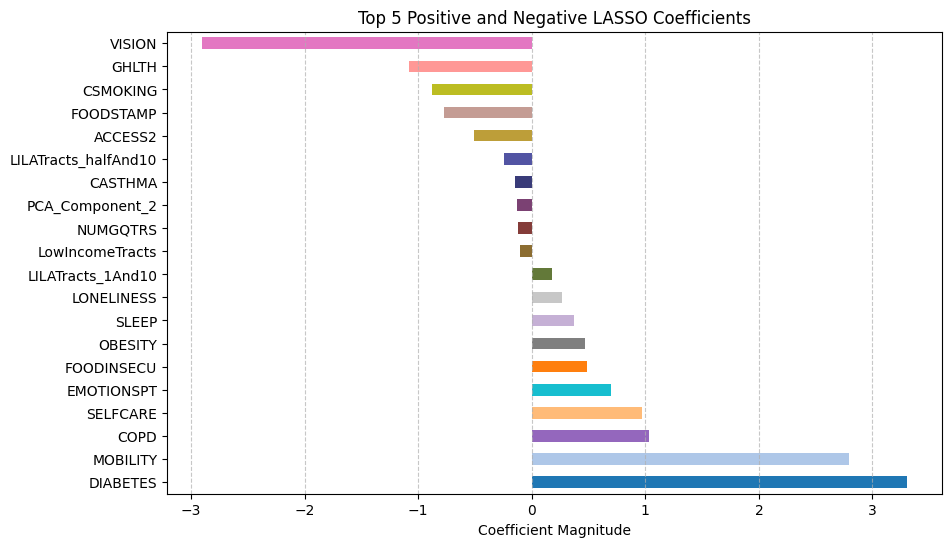

In [50]:
# Plot the top and bottom 5 (10 total)
top_bottom = pd.concat([selected_features_series.head(10), selected_features_series.tail(10)])
coefficient_colors = [VARIABLE_COLORS[feature] for feature in top_bottom.index]

plt.figure(figsize=(10, 6))
top_bottom.plot(kind='barh', color=coefficient_colors)
plt.title('Top 5 Positive and Negative LASSO Coefficients')
plt.xlabel('Coefficient Magnitude')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 6. Reporting and Validation

In [51]:
# Create a results DataFrame to hold predictions and identify rows
results = pd.DataFrame({
    'Actual': y_test.values.ravel(),
    'Predicted': lasso_pipeline.predict(X_test_model)
}, index=X_test.index)

# Join the identifiers back ONLY to the results
results = results.join(X_test[['locationname', 'State']])

print(results.head())

      Actual  Predicted locationname      State
2085    32.4  33.055838      Hancock       Ohio
2505    37.5  37.022787      Overton  Tennessee
939     31.6  34.035286      Haskell     Kansas
1342    28.7  27.777375    Crow Wing  Minnesota
2219    30.0  31.841000        Baker     Oregon


The sample predictions indicate that the model produces estimates that are generally close to the observed hypertension prevalence.  For example, Hancock, OH prediction is 33.05 and the actual value is 42.4, which is almost identical. This shows that LASSO slection is doing a solid job of capturing hypertension risk in the dataset.

Although only a small subset of predictions is displayed, this provides an initial qualitative validation that the model is generating reasonable estimates. A comprehensive assessment of predictive performance will be conducted using quantitative evaluation metrics, including Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and the coefficient of determination (R²), across the entire test dataset.

## 8. Findings and Next Steps

| Task | Result | Decision |
|---|---|---|
| Feature Selection | LASSO identified 33 key predictors | Retain these features for the final model |
| Regularization Parameter | Optimal alpha = 0.0059 | Use this alpha in the final modeling pipeline, derived from LassoCV cross-validation |
| Model Evaluation | Predictions closely match actual values | Proceed to integrate into the final modeling pipeline |

**Next steps.** 
The parameters identified through this LASSO analysis ($\alpha=0.0059$) will serve as the foundation for the final predictive modeling pipeline. To maintain the integrity of the held-out test set and adhere to best practices in preventing data leakage, all formal model evaluation is reserved for the final integrated pipeline. The subsequent phase will involve Principal Component Analysis (PCA) to assess dimensionality reduction. Findings from the PCA will be evaluated alongside the current LASSO-selected features to determine the most effective strategy for the Hypertension Risk Atlas predictive model.